DATA
X: (118, 40064)
animals: 57
non-animals: 61
d/n: 339.52542372881356

FISHER k = 5
Fold 118/118 | Fisher rank=116

FISHER k = 10
Fold 118/118 | Fisher rank=116

FISHER k = 20
Fold 118/118 | Fisher rank=116

FISHER k = 40
Fold 118/118 | Fisher rank=116

FISHER k = 60
Fold 118/118 | Fisher rank=116

FISHER k = 80
Fold 118/118 | Fisher rank=116

FISHER k = 100
Fold 118/118 | Fisher rank=116


FISHER-PROJECTION LOO RESULTS
     k     Accuracy      Bal Acc          AUC          BCE
-------------------------------------------------------------------------------------
     5       0.5593       0.5559       0.6198       0.6753
    10       0.6102       0.6068       0.6759       0.6485
    20       0.6017       0.5975       0.6756       0.6490
    40       0.6949       0.6940       0.7929       0.9597
    60       0.6864       0.6852       0.7854       0.7814
    80       0.6864       0.6852       0.7875       0.7615
   100       0.6864       0.6852       0.7852       0.7553

Best k by BCE:

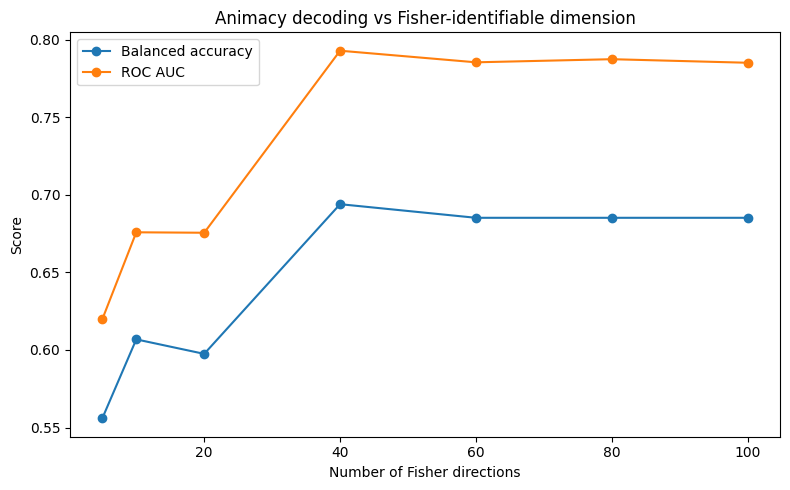

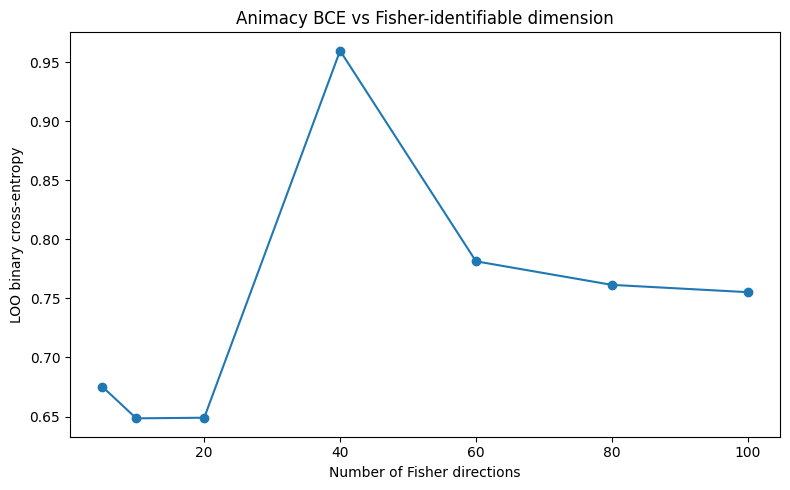


FULL-DATA FISHER GEOMETRY
Fisher rank: 117
Null-space dimension: 39947
Mean logistic Fisher weight: 0.01052699693975212
Min logistic Fisher weight: 0.0007183285656485515
Max logistic Fisher weight: 0.022342992885757265


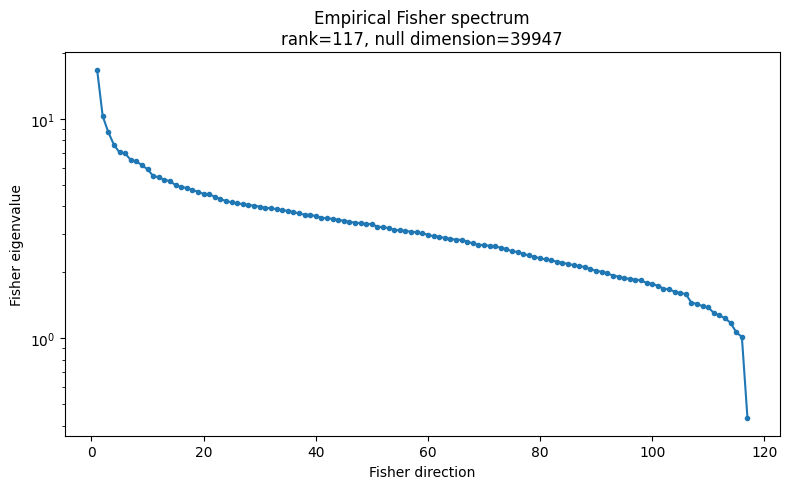

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    log_loss,
    confusion_matrix,
)


# ============================================================
# CONFIG
# ============================================================

DATA_PATH = (
    "/home/maria/SelfStudyThesis/data/"
    "allen_natural_scenes_four_class_composite.npy"
)

# Fisher dimensions to test.
# These are selected using training data only via an inner LOO-like
# criterion below.
K_GRID = [5, 10, 20, 40, 60, 80, 100]

# Regularization for the logistic model used to construct W.
# This MUST be regularized because d >> n.
FISHER_C = 0.01

# Logistic regularization after Fisher projection.
FINAL_C = 1.0

MAX_ITER = 5000
SEED = 42


# ============================================================
# 1. LOAD DATA
# ============================================================

dat = np.load(DATA_PATH, allow_pickle=True).item()

X = np.asarray(dat["X"], dtype=np.float64).T
labels = np.asarray(dat["stimulus_metadata"]["label"])

# Animal = 1
# Everything else = 0
y = (labels == 0).astype(int)

n, d = X.shape

print("=" * 70)
print("DATA")
print("=" * 70)

print("X:", X.shape)
print("animals:", y.sum())
print("non-animals:", (1 - y).sum())
print("d/n:", d / n)


# ============================================================
# 2. HELPER: FIT FISHER SUBSPACE
# ============================================================
#
# Input:
#
#       X_train : training neural responses
#       y_train : training labels
#       k       : requested Fisher dimension
#
# Output:
#
#       scaler
#       mean used after scaling
#       Fisher basis V_k
#       Fisher eigenvalues
#
#
# IMPORTANT:
#
# Everything is learned from X_train/y_train ONLY.
#
# We never construct the d x d Fisher matrix.
#
# Instead:
#
#       I = X^T W X / n
#
# and
#
#       X_w = sqrt(W) X
#
# so
#
#       I = X_w^T X_w / n.
#
# Therefore the right singular vectors of X_w are the
# Fisher eigenvectors.
#

def fit_fisher_subspace(X_train, y_train, k):

    # --------------------------------------------------------
    # Standardize using TRAINING data only
    # --------------------------------------------------------

    scaler = StandardScaler()

    Xs = scaler.fit_transform(X_train)

    # Center again explicitly.
    #
    # StandardScaler already centers, but keeping this explicit
    # makes the geometry obvious.
    fisher_mean = Xs.mean(axis=0, keepdims=True)

    Xc = Xs - fisher_mean


    # --------------------------------------------------------
    # Preliminary regularized logistic model
    # --------------------------------------------------------
    #
    # We need beta_hat in order to estimate
    #
    #       p_i
    #
    # and hence
    #
    #       W_i = p_i(1-p_i).
    #
    # L2 regularization makes the fit well-defined in d >> n.
    #

    preliminary = LogisticRegression(
        penalty="l2",
        C=FISHER_C,
        solver="liblinear",
        max_iter=MAX_ITER,
        random_state=SEED,
    )

    preliminary.fit(Xc, y_train)

    p = preliminary.predict_proba(Xc)[:, 1]

    # Avoid exact numerical 0/1.
    eps = 1e-8
    p = np.clip(p, eps, 1.0 - eps)

    w = p * (1.0 - p)


    # --------------------------------------------------------
    # Weighted design
    # --------------------------------------------------------
    #
    # Fisher:
    #
    #       I = Xc^T W Xc / n
    #
    # Define:
    #
    #       Xw = sqrt(W) Xc
    #
    # then:
    #
    #       I = Xw^T Xw / n
    #

    Xw = Xc * np.sqrt(w)[:, None]


    # --------------------------------------------------------
    # Thin SVD
    # --------------------------------------------------------

    U, s, Vt = np.linalg.svd(
        Xw,
        full_matrices=False,
    )

    # Numerical rank
    tol = s[0] * 1e-10
    rank = np.sum(s > tol)

    k_eff = min(k, rank)

    V_k = Vt[:k_eff].T

    fisher_eigenvalues = (s[:rank] ** 2) / len(y_train)

    return (
        scaler,
        fisher_mean,
        V_k,
        fisher_eigenvalues,
        rank,
        w,
    )


# ============================================================
# 3. HELPER: TRANSFORM DATA INTO FISHER SPACE
# ============================================================

def fisher_transform(X_new, scaler, fisher_mean, V_k):

    Xs = scaler.transform(X_new)

    Xc = Xs - fisher_mean

    return Xc @ V_k


# ============================================================
# 4. OUTER LOO
# ============================================================
#
# We evaluate each k separately first.
#
# This gives:
#
#       k -> held-out BCE
#       k -> accuracy
#       k -> balanced accuracy
#       k -> AUC
#
# Every Fisher basis is reconstructed independently inside
# each LOO training fold.
#

outer = LeaveOneOut()

results = {}

for k in K_GRID:

    print("\n" + "=" * 70)
    print(f"FISHER k = {k}")
    print("=" * 70)

    prob = np.zeros(n)

    ranks = np.zeros(n)
    mean_weights = np.zeros(n)

    for fold, (train_idx, test_idx) in enumerate(
        outer.split(X, y),
        1
    ):

        X_train = X[train_idx]
        y_train = y[train_idx]

        X_test = X[test_idx]


        # ----------------------------------------------------
        # Fisher subspace from TRAINING fold only
        # ----------------------------------------------------

        (
            scaler,
            fisher_mean,
            V_k,
            fisher_eigs,
            fisher_rank,
            fisher_weights,
        ) = fit_fisher_subspace(
            X_train,
            y_train,
            k,
        )

        ranks[test_idx] = fisher_rank
        mean_weights[test_idx] = fisher_weights.mean()


        # ----------------------------------------------------
        # Project train and test
        # ----------------------------------------------------

        Z_train = fisher_transform(
            X_train,
            scaler,
            fisher_mean,
            V_k,
        )

        Z_test = fisher_transform(
            X_test,
            scaler,
            fisher_mean,
            V_k,
        )


        # ----------------------------------------------------
        # Final logistic decoder in Fisher space
        # ----------------------------------------------------

        classifier = LogisticRegression(
            penalty="l2",
            C=FINAL_C,
            solver="liblinear",
            max_iter=MAX_ITER,
            random_state=SEED,
        )

        classifier.fit(Z_train, y_train)

        prob[test_idx] = classifier.predict_proba(
            Z_test
        )[:, 1]


        if fold % 20 == 0 or fold == n:

            print(
                f"\rFold {fold:3d}/{n} | "
                f"Fisher rank={fisher_rank:3d}",
                end=""
            )

    print()

    pred = (prob >= 0.5).astype(int)

    results[k] = {
        "prob": prob,
        "pred": pred,
        "accuracy": accuracy_score(y, pred),
        "balanced_accuracy":
            balanced_accuracy_score(y, pred),
        "auc": roc_auc_score(y, prob),
        "bce": log_loss(y, prob),
        "mean_rank": ranks.mean(),
        "mean_weight": mean_weights.mean(),
    }


# ============================================================
# 5. REPORT RESULTS
# ============================================================

print("\n")
print("=" * 85)
print("FISHER-PROJECTION LOO RESULTS")
print("=" * 85)

print(
    f"{'k':>6} "
    f"{'Accuracy':>12} "
    f"{'Bal Acc':>12} "
    f"{'AUC':>12} "
    f"{'BCE':>12}"
)

print("-" * 85)

for k in K_GRID:

    r = results[k]

    print(
        f"{k:6d} "
        f"{r['accuracy']:12.4f} "
        f"{r['balanced_accuracy']:12.4f} "
        f"{r['auc']:12.4f} "
        f"{r['bce']:12.4f}"
    )


# ============================================================
# 6. SELECT BEST k
# ============================================================
#
# For this exploratory experiment we report the complete curve.
#
# IMPORTANT:
#
# Choosing the best k from these same outer-LOO predictions
# and then quoting its accuracy as an unbiased final estimate
# would be optimistic.
#
# If we later want ONE definitive Fisher model, k should be
# selected in an additional inner CV loop.
#
# For now the curve itself is the scientific result.
#

best_k_bce = min(
    K_GRID,
    key=lambda k: results[k]["bce"]
)

best_k_bal = max(
    K_GRID,
    key=lambda k: results[k]["balanced_accuracy"]
)

print("\nBest k by BCE:", best_k_bce)
print("Best k by balanced accuracy:", best_k_bal)


# ============================================================
# 7. DETAILS FOR BEST-BCE MODEL
# ============================================================

best = results[best_k_bce]

print("\n" + "=" * 70)
print(f"BEST FISHER MODEL: k={best_k_bce}")
print("=" * 70)

print(
    "Accuracy:         ",
    f"{best['accuracy']:.4f}"
)

print(
    "Balanced accuracy:",
    f"{best['balanced_accuracy']:.4f}"
)

print(
    "ROC AUC:          ",
    f"{best['auc']:.4f}"
)

print(
    "BCE:              ",
    f"{best['bce']:.4f}"
)

print("\nConfusion matrix:")

print(
    confusion_matrix(
        y,
        best["pred"]
    )
)


# ============================================================
# 8. PLOT PERFORMANCE VS FISHER DIMENSION
# ============================================================

ks = np.array(K_GRID)

bal_accs = np.array([
    results[k]["balanced_accuracy"]
    for k in K_GRID
])

aucs = np.array([
    results[k]["auc"]
    for k in K_GRID
])

bces = np.array([
    results[k]["bce"]
    for k in K_GRID
])


plt.figure(figsize=(8, 5))

plt.plot(
    ks,
    bal_accs,
    marker="o",
    label="Balanced accuracy",
)

plt.plot(
    ks,
    aucs,
    marker="o",
    label="ROC AUC",
)

plt.xlabel("Number of Fisher directions")
plt.ylabel("Score")
plt.title(
    "Animacy decoding vs Fisher-identifiable dimension"
)

plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    ks,
    bces,
    marker="o",
)

plt.xlabel("Number of Fisher directions")
plt.ylabel("LOO binary cross-entropy")
plt.title(
    "Animacy BCE vs Fisher-identifiable dimension"
)

plt.tight_layout()
plt.show()


# ============================================================
# 9. FIT FISHER MODEL TO FULL DATA FOR INSPECTION
# ============================================================
#
# NOT used to estimate predictive performance.
#

(
    final_scaler,
    final_mean,
    final_V,
    final_fisher_eigs,
    final_rank,
    final_weights,
) = fit_fisher_subspace(
    X,
    y,
    best_k_bce,
)


print("\n" + "=" * 70)
print("FULL-DATA FISHER GEOMETRY")
print("=" * 70)

print("Fisher rank:", final_rank)

print(
    "Null-space dimension:",
    d - final_rank
)

print(
    "Mean logistic Fisher weight:",
    final_weights.mean()
)

print(
    "Min logistic Fisher weight:",
    final_weights.min()
)

print(
    "Max logistic Fisher weight:",
    final_weights.max()
)


# ============================================================
# 10. FISHER EIGENVALUE SPECTRUM
# ============================================================

plt.figure(figsize=(8, 5))

plt.semilogy(
    np.arange(1, len(final_fisher_eigs) + 1),
    final_fisher_eigs,
    marker=".",
)

plt.xlabel("Fisher direction")
plt.ylabel("Fisher eigenvalue")

plt.title(
    f"Empirical Fisher spectrum\n"
    f"rank={final_rank}, "
    f"null dimension={d-final_rank}"
)

plt.tight_layout()
plt.show()

DATA
X: (118, 40064)
animals: 57
non-animals: 61
d/n: 339.52542372881356

OBSERVED FISHER-LOO EXPERIMENT
LOO fold 118/118

Observed results:
     k      Accuracy       Bal Acc           AUC
--------------------------------------------------
     5        0.5593        0.5559        0.6198
    10        0.6102        0.6068        0.6759
    20        0.6017        0.5975        0.6756
    40        0.6949        0.6940        0.7929
    60        0.6864        0.6852        0.7854
    80        0.6864        0.6852        0.7875
   100        0.6864        0.6852        0.7852

OBSERVED TEST STATISTIC
Winning k: 40
Observed max balanced accuracy: 0.6939890710382514
AUC at winning k: 0.7929249352890423

PERMUTATION NULL
Permutation   20/20 | T=0.4751 | best k= 60

GLOBAL PERMUTATION TEST
Observed max balanced accuracy: 0.6939890710382514
Observed winning k: 40

Permutation null:
mean:          0.546433707218867
SD:            0.057547068408871783
median:        0.53839516824849
95% quan

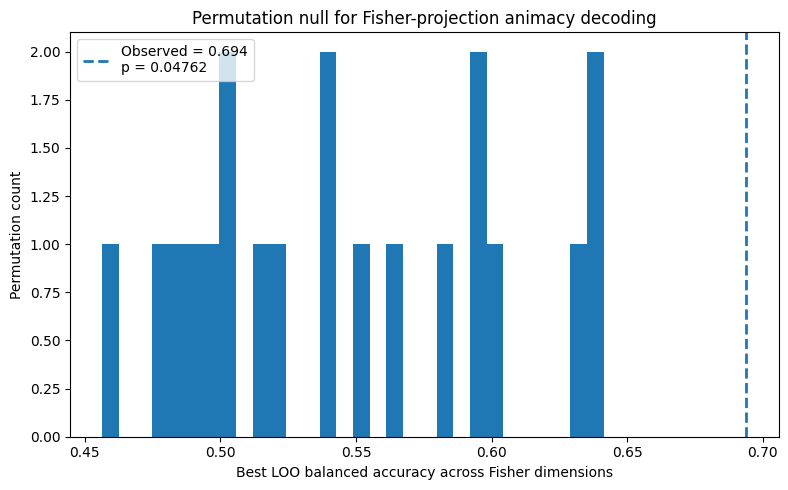

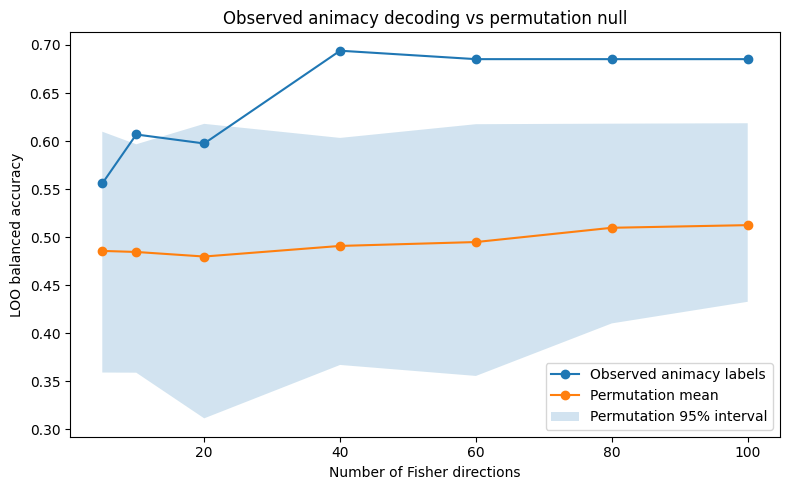


WINNING k UNDER THE NULL
k=  5:    3 / 20 (0.150)
k= 10:    3 / 20 (0.150)
k= 20:    4 / 20 (0.200)
k= 60:    3 / 20 (0.150)
k= 80:    2 / 20 (0.100)
k=100:    5 / 20 (0.250)

Saved:
  fisher_loo_permutation_results.npz
  fisher_loo_permutation_null.png
  fisher_dimension_vs_null.png


In [8]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    roc_auc_score,
)

# ============================================================
# CONFIG
# ============================================================

DATA_PATH = (
    "/home/maria/SelfStudyThesis/data/"
    "allen_natural_scenes_four_class_composite.npy"
)

K_GRID = [5, 10, 20, 40, 60, 80, 100]

FISHER_C = 0.01
FINAL_C = 1.0
MAX_ITER = 5000

N_PERM = 20       # Start with 20 for a smoke test
SEED = 42
SVD_RTOL = 1e-10


# ============================================================
# 1. LOAD DATA
# ============================================================

dat = np.load(DATA_PATH, allow_pickle=True).item()

X = np.asarray(dat["X"], dtype=np.float64)
labels = np.asarray(dat["stimulus_metadata"]["label"])

# Animal = 1
# Everything else = 0
y = (labels == 0).astype(int)

# Ensure X = (stimuli, features)
if X.shape[0] == len(y):
    pass
elif X.shape[1] == len(y):
    X = X.T
else:
    raise ValueError(
        f"Cannot align X shape {X.shape} with {len(y)} labels."
    )

n, d = X.shape

print("=" * 75)
print("DATA")
print("=" * 75)
print("X:", X.shape)
print("animals:", y.sum())
print("non-animals:", (1 - y).sum())
print("d/n:", d / n)


# ============================================================
# 2. FIT FISHER BASIS
# ============================================================
#
# Everything here is fitted using TRAINING DATA ONLY.
#
# Preliminary logistic:
#
#       X_train -> beta_prelim -> p_i
#
# Logistic weights:
#
#       w_i = p_i (1-p_i)
#
# Fisher:
#
#       I = X^T W X / n
#
# Instead of constructing d x d Fisher:
#
#       Xw = sqrt(W) X
#
# and SVD(Xw) gives the Fisher eigenvectors.
#

def fit_fisher_basis(X_train, y_train):

    scaler = StandardScaler()
    Xs = scaler.fit_transform(X_train)

    # StandardScaler has already centered Xs.
    fisher_mean = Xs.mean(axis=0, keepdims=True)
    Xc = Xs - fisher_mean

    preliminary = LogisticRegression(
        penalty="l2",
        C=FISHER_C,
        solver="liblinear",
        max_iter=MAX_ITER,
        random_state=SEED,
    )

    preliminary.fit(Xc, y_train)

    p = preliminary.predict_proba(Xc)[:, 1]

    eps = 1e-8
    p = np.clip(p, eps, 1.0 - eps)

    w = p * (1.0 - p)

    # Weighted design
    Xw = Xc * np.sqrt(w)[:, None]

    # Thin SVD
    _, s, Vt = np.linalg.svd(
        Xw,
        full_matrices=False,
    )

    tol = s[0] * SVD_RTOL
    rank = int(np.sum(s > tol))

    return scaler, fisher_mean, Vt[:rank].T, rank


# ============================================================
# 3. TRANSFORM USING FISHER BASIS
# ============================================================

def fisher_transform(X_new, scaler, fisher_mean, V):

    Xs = scaler.transform(X_new)
    Xc = Xs - fisher_mean

    return Xc @ V


# ============================================================
# 4. ONE COMPLETE LOO FISHER EXPERIMENT
# ============================================================
#
# IMPORTANT:
#
# For each outer fold:
#
#   1. scale training data
#   2. fit preliminary logistic model
#   3. construct Fisher basis
#   4. project into each k
#   5. fit final logistic model
#   6. predict the one unseen stimulus
#
# The held-out stimulus NEVER participates in the Fisher basis.
#
# One Fisher basis is constructed per fold.
# Because k=5,10,... are nested prefixes of the same basis,
# we reuse it for all k.
#

def run_fisher_loo(X, y_current, verbose=False):

    loo = LeaveOneOut()

    probabilities = {
        k: np.zeros(n, dtype=float)
        for k in K_GRID
    }

    for fold, (train_idx, test_idx) in enumerate(
        loo.split(X, y_current),
        start=1,
    ):

        X_train = X[train_idx]
        y_train = y_current[train_idx]

        X_test = X[test_idx]

        # -----------------------------------------------
        # Fisher geometry from training fold only
        # -----------------------------------------------

        (
            scaler,
            fisher_mean,
            V,
            rank,
        ) = fit_fisher_basis(
            X_train,
            y_train,
        )

        # -----------------------------------------------
        # Project ONCE into complete Fisher basis
        # -----------------------------------------------

        Z_train_full = fisher_transform(
            X_train,
            scaler,
            fisher_mean,
            V,
        )

        Z_test_full = fisher_transform(
            X_test,
            scaler,
            fisher_mean,
            V,
        )

        # -----------------------------------------------
        # Test all k as prefixes of Fisher basis
        # -----------------------------------------------

        for k in K_GRID:

            k_eff = min(k, rank)

            Z_train = Z_train_full[:, :k_eff]
            Z_test = Z_test_full[:, :k_eff]

            classifier = LogisticRegression(
                penalty="l2",
                C=FINAL_C,
                solver="liblinear",
                max_iter=MAX_ITER,
                random_state=SEED,
            )

            classifier.fit(
                Z_train,
                y_train,
            )

            probabilities[k][test_idx[0]] = (
                classifier.predict_proba(Z_test)[0, 1]
            )

        if verbose and (
            fold % 20 == 0 or fold == n
        ):
            print(
                f"\rLOO fold {fold:3d}/{n}",
                end="",
                flush=True,
            )

    if verbose:
        print()

    # ----------------------------------------------------
    # Evaluate all k
    # ----------------------------------------------------

    metrics = {}

    for k in K_GRID:

        prob = probabilities[k]
        pred = (prob >= 0.5).astype(int)

        metrics[k] = {
            "balanced_accuracy":
                balanced_accuracy_score(y_current, pred),

            "accuracy":
                accuracy_score(y_current, pred),

            "auc":
                roc_auc_score(y_current, prob),
        }

    return metrics, probabilities


# ============================================================
# 5. OBSERVED LABELS
# ============================================================

print("\n" + "=" * 75)
print("OBSERVED FISHER-LOO EXPERIMENT")
print("=" * 75)

observed_metrics, observed_prob = run_fisher_loo(
    X,
    y,
    verbose=True,
)

print("\nObserved results:")

print(
    f"{'k':>6}"
    f"{'Accuracy':>14}"
    f"{'Bal Acc':>14}"
    f"{'AUC':>14}"
)

print("-" * 50)

for k in K_GRID:

    m = observed_metrics[k]

    print(
        f"{k:6d}"
        f"{m['accuracy']:14.4f}"
        f"{m['balanced_accuracy']:14.4f}"
        f"{m['auc']:14.4f}"
    )


# ============================================================
# 6. OBSERVED TEST STATISTIC
# ============================================================
#
# We searched over k.
#
# Therefore the statistic is NOT:
#
#       balanced accuracy at k=40
#
# but:
#
#       max balanced accuracy across K_GRID.
#
# Every permutation gets exactly the same search privilege.
#

observed_bal_accs = np.array([
    observed_metrics[k]["balanced_accuracy"]
    for k in K_GRID
])

best_idx = np.argmax(observed_bal_accs)
best_k = K_GRID[best_idx]
T_obs = observed_bal_accs[best_idx]

print("\n" + "=" * 75)
print("OBSERVED TEST STATISTIC")
print("=" * 75)

print("Winning k:", best_k)
print("Observed max balanced accuracy:", T_obs)
print("AUC at winning k:", observed_metrics[best_k]["auc"])


# ============================================================
# 7. PERMUTATION NULL
# ============================================================
#
# H0:
#
#       Y is exchangeable with respect to X.
#
# For every permutation:
#
#       permute Y
#           |
#           v
#       repeat entire LOO procedure
#           |
#           v
#       construct Fisher basis INSIDE each training fold
#           |
#           v
#       search all k
#           |
#           v
#       keep BEST balanced accuracy
#
# This gives the null distribution for the ENTIRE procedure.
#

rng = np.random.default_rng(SEED)

T_perm = np.zeros(N_PERM, dtype=float)
best_k_perm = np.zeros(N_PERM, dtype=int)

# Also save the whole k x permutation matrix.
perm_bal_acc = np.zeros(
    (N_PERM, len(K_GRID)),
    dtype=float,
)

print("\n" + "=" * 75)
print("PERMUTATION NULL")
print("=" * 75)

for b in range(N_PERM):

    y_perm = rng.permutation(y)

    perm_metrics, _ = run_fisher_loo(
        X,
        y_perm,
        verbose=False,
    )

    scores = np.array([
        perm_metrics[k]["balanced_accuracy"]
        for k in K_GRID
    ])

    perm_bal_acc[b, :] = scores

    winner = np.argmax(scores)

    T_perm[b] = scores[winner]
    best_k_perm[b] = K_GRID[winner]

    print(
        f"\rPermutation "
        f"{b + 1:4d}/{N_PERM} | "
        f"T={T_perm[b]:.4f} | "
        f"best k={best_k_perm[b]:3d}",
        end="",
        flush=True,
    )

print()


# ============================================================
# 8. GLOBAL PERMUTATION P-VALUE
# ============================================================
#
# +1 correction:
#
#       p = (1 + # null >= observed) / (B + 1)
#

n_extreme = np.sum(T_perm >= T_obs)

p_value = (
    1 + n_extreme
) / (
    N_PERM + 1
)


print("\n" + "=" * 75)
print("GLOBAL PERMUTATION TEST")
print("=" * 75)

print("Observed max balanced accuracy:", T_obs)
print("Observed winning k:", best_k)

print("\nPermutation null:")
print("mean:         ", T_perm.mean())
print("SD:           ", T_perm.std(ddof=1))
print("median:       ", np.median(T_perm))
print("95% quantile: ", np.quantile(T_perm, 0.95))
print("99% quantile: ", np.quantile(T_perm, 0.99))
print("maximum:      ", T_perm.max())

print("\nNull values >= observed:", n_extreme)
print("Permutation p-value:", p_value)


# ============================================================
# 9. EFFECT SIZE RELATIVE TO NULL
# ============================================================

null_sd = T_perm.std(ddof=1)

if null_sd > 0:

    z_perm = (
        T_obs - T_perm.mean()
    ) / null_sd

else:

    z_perm = np.nan

print("Permutation z-score:", z_perm)


# ============================================================
# 10. OPTIONAL: k-SPECIFIC P-VALUES
# ============================================================
#
# These are useful descriptively.
#
# The GLOBAL max-k p-value above is the important one because
# it corrects for our search across Fisher dimensions.
#

print("\n" + "=" * 75)
print("k-SPECIFIC PERMUTATION RESULTS")
print("=" * 75)

print(
    f"{'k':>6}"
    f"{'Observed':>14}"
    f"{'Null mean':>14}"
    f"{'p':>14}"
)

print("-" * 50)

p_by_k = {}

for j, k in enumerate(K_GRID):

    observed = observed_bal_accs[j]
    null = perm_bal_acc[:, j]

    p_k = (
        1 + np.sum(null >= observed)
    ) / (
        N_PERM + 1
    )

    p_by_k[k] = p_k

    print(
        f"{k:6d}"
        f"{observed:14.4f}"
        f"{null.mean():14.4f}"
        f"{p_k:14.6f}"
    )


# ============================================================
# 11. PLOT GLOBAL NULL DISTRIBUTION
# ============================================================

plt.figure(figsize=(8, 5))

# Robust bins even if the null distribution is narrow.
lo = T_perm.min()
hi = T_perm.max()

if np.isclose(lo, hi):

    bins = np.linspace(
        lo - 0.01,
        hi + 0.01,
        10,
    )

else:

    bins = np.linspace(
        lo,
        hi,
        31,
    )

plt.hist(
    T_perm,
    bins=bins,
)

plt.axvline(
    T_obs,
    linestyle="--",
    linewidth=2,
    label=(
        f"Observed = {T_obs:.3f}\n"
        f"p = {p_value:.4g}"
    ),
)

plt.xlabel(
    "Best LOO balanced accuracy across Fisher dimensions"
)

plt.ylabel(
    "Permutation count"
)

plt.title(
    "Permutation null for Fisher-projection animacy decoding"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "fisher_loo_permutation_null.png",
    dpi=200,
)

plt.show()


# ============================================================
# 12. PLOT OBSERVED PERFORMANCE VS NULL BY k
# ============================================================

null_mean_by_k = perm_bal_acc.mean(axis=0)

null_q025 = np.quantile(
    perm_bal_acc,
    0.025,
    axis=0,
)

null_q975 = np.quantile(
    perm_bal_acc,
    0.975,
    axis=0,
)


plt.figure(figsize=(8, 5))

plt.plot(
    K_GRID,
    observed_bal_accs,
    marker="o",
    label="Observed animacy labels",
)

plt.plot(
    K_GRID,
    null_mean_by_k,
    marker="o",
    label="Permutation mean",
)

plt.fill_between(
    K_GRID,
    null_q025,
    null_q975,
    alpha=0.2,
    label="Permutation 95% interval",
)

plt.xlabel(
    "Number of Fisher directions"
)

plt.ylabel(
    "LOO balanced accuracy"
)

plt.title(
    "Observed animacy decoding vs permutation null"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "fisher_dimension_vs_null.png",
    dpi=200,
)

plt.show()


# ============================================================
# 13. WHICH k DOES RANDOM SEARCH PREFER?
# ============================================================

unique_k, counts = np.unique(
    best_k_perm,
    return_counts=True,
)

print("\n" + "=" * 75)
print("WINNING k UNDER THE NULL")
print("=" * 75)

for k, count in zip(unique_k, counts):

    print(
        f"k={k:3d}: "
        f"{count:4d} / {N_PERM} "
        f"({count / N_PERM:.3f})"
    )


# ============================================================
# 14. SAVE RESULTS
# ============================================================

np.savez(
    "fisher_loo_permutation_results.npz",

    K_GRID=np.asarray(K_GRID),

    observed_bal_acc=observed_bal_accs,
    observed_best_k=best_k,
    T_obs=T_obs,

    T_perm=T_perm,
    perm_bal_acc=perm_bal_acc,
    best_k_perm=best_k_perm,

    p_value=p_value,
    p_by_k=np.asarray([
        p_by_k[k]
        for k in K_GRID
    ]),

    seed=SEED,
    n_perm=N_PERM,
)

print("\nSaved:")
print("  fisher_loo_permutation_results.npz")
print("  fisher_loo_permutation_null.png")
print("  fisher_dimension_vs_null.png")

DATA
X: (118, 40064)
animals: 57
non-animals: 61
d/n: 339.52542372881356

Parallel configuration:
N_PERM: 1000
N_JOBS: -1

OBSERVED FISHER-LOO EXPERIMENT
Observed analysis finished in 185.9 seconds.

Observed results:
     k      Accuracy       Bal Acc           AUC
--------------------------------------------------
     5        0.5593        0.5559        0.6198
    10        0.6102        0.6068        0.6759
    20        0.6017        0.5975        0.6756
    40        0.6949        0.6940        0.7929
    60        0.6864        0.6852        0.7854
    80        0.6864        0.6852        0.7875
   100        0.6864        0.6852        0.7852

OBSERVED TEST STATISTIC
Winning k: 40
Observed max balanced accuracy: 0.6939890710382514
AUC at winning k: 0.7929249352890423

PARALLEL PERMUTATION NULL
Running 1000 permutations with N_JOBS=-1


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed: 23.2min
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed: 24.0min
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed: 25.4min
[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed: 48.7min
[Parallel(n_jobs=-1)]: Done  50 tasks      | elapsed: 70.3min
[Parallel(n_jobs=-1)]: Done  65 tasks      | elapsed: 71.3min
[Parallel(n_jobs=-1)]: Done  80 tasks      | elapsed: 93.4min
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed: 117.1min
[Parallel(n_jobs=-1)]: Done 114 tasks      | elapsed: 118.8min
[Parallel(n_jobs=-1)]: Done 133 tasks      | elapsed: 142.4min
[Parallel(n_jobs=-1)]: Done 152 tasks      | elapsed: 165.4min
[Parallel(n_jobs=-1)]: Done 173 tasks      | elapsed: 189.0min
[Parallel(n_jobs=-1)]: Done 194 tasks      | elapsed: 214.1min
[Parallel(n_jobs=-1)]: Done 217 tasks      | elapsed: 238.6min
[Parallel(n_jobs=-1)]: Done 240 tasks      | ela


Parallel permutation stage finished in 55209.8 seconds.
Average wall-clock time per permutation: 55.20982675695419

GLOBAL PERMUTATION TEST
Observed max balanced accuracy: 0.6939890710382514
Observed winning k: 40

Permutation null:
mean:           0.5288354903652575
SD:             0.05056904804933665
median:         0.5287604256542997
95% quantile:   0.6114466494104113
99% quantile:   0.6454429105550761
maximum:        0.6846419327006039

Null values >= observed: 0
Permutation p-value: 0.000999000999000999
Permutation z-score: 3.265902504470031

k-SPECIFIC PERMUTATION RESULTS
     k      Observed     Null mean      95% null             p
-----------------------------------------------------------------
     5        0.5559        0.4639        0.5641      0.072927
    10        0.6068        0.4679        0.5735      0.016983
    20        0.5975        0.4700        0.5665      0.020979
    40        0.6940        0.4760        0.5746      0.000999
    60        0.6852        0.494

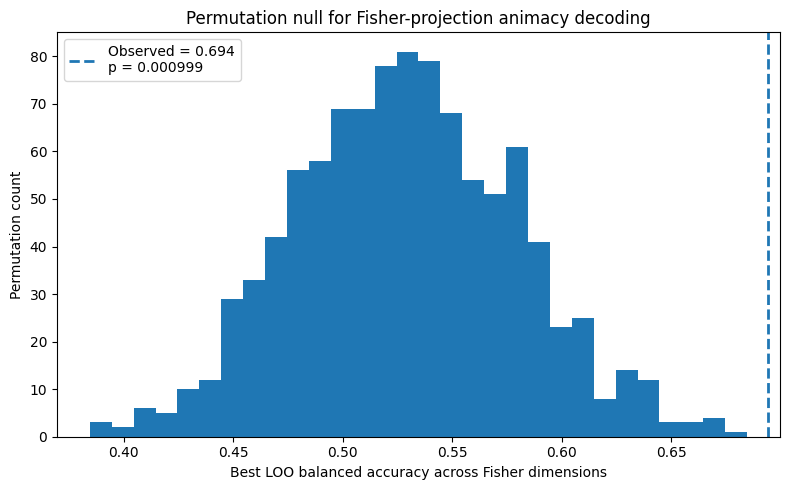

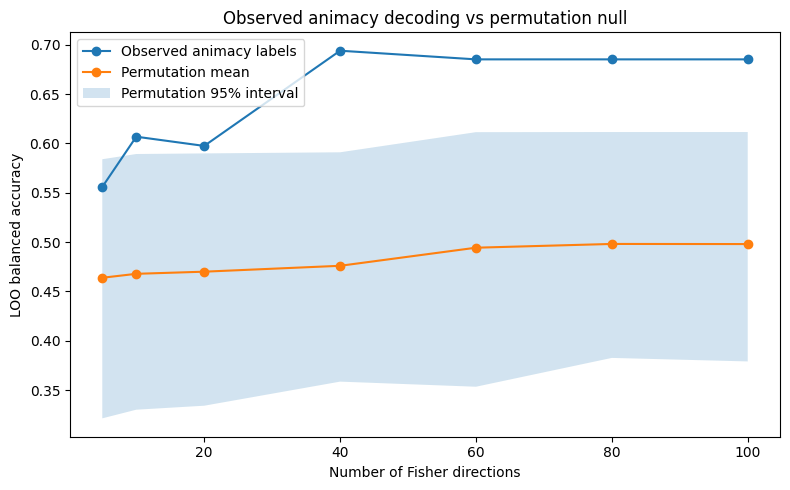


DONE
Observed T: 0.6939890710382514
Extreme permutations: 0 / 1000
Global permutation p: 0.000999000999000999

Saved:
  fisher_parallel_permutation_results.npz
  fisher_parallel_permutation_null.png
  fisher_parallel_dimension_vs_null.png


In [1]:
import os

# ============================================================
# IMPORTANT: limit BLAS threading BEFORE importing numpy
# ============================================================
#
# Each permutation runs in its own process.
# We do not want every process spawning a full set of
# OpenBLAS/MKL threads internally.
#

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"


import time
import numpy as np
import matplotlib.pyplot as plt

from joblib import Parallel, delayed
from threadpoolctl import threadpool_limits

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    roc_auc_score,
)


# ============================================================
# CONFIG
# ============================================================

DATA_PATH = (
    "/home/maria/SelfStudyThesis/data/"
    "allen_natural_scenes_four_class_composite.npy"
)

K_GRID = [5, 10, 20, 40, 60, 80, 100]

FISHER_C = 0.01
FINAL_C = 1.0
MAX_ITER = 5000

# ------------------------------------------------------------
# PERMUTATION SETTINGS
# ------------------------------------------------------------

N_PERM = 1000

# -1 = all available CPU cores.
#
# If this makes the machine unusable, try:
#
# N_JOBS = 8
#
N_JOBS = -1

SEED = 42
SVD_RTOL = 1e-10


# ============================================================
# 1. LOAD DATA
# ============================================================

dat = np.load(
    DATA_PATH,
    allow_pickle=True,
).item()

X = np.asarray(
    dat["X"],
    dtype=np.float64,
)

labels = np.asarray(
    dat["stimulus_metadata"]["label"]
)

# ------------------------------------------------------------
# Animal = 1
# Everything else = 0
# ------------------------------------------------------------

y = (labels == 0).astype(int)


# ------------------------------------------------------------
# Ensure:
#
#       X = (stimuli, features)
# ------------------------------------------------------------

if X.shape[0] == len(y):

    pass

elif X.shape[1] == len(y):

    X = X.T

else:

    raise ValueError(
        f"Cannot align X shape {X.shape} "
        f"with {len(y)} labels."
    )


n, d = X.shape


print("=" * 75)
print("DATA")
print("=" * 75)

print("X:", X.shape)
print("animals:", y.sum())
print("non-animals:", (1 - y).sum())
print("d/n:", d / n)

print("\nParallel configuration:")
print("N_PERM:", N_PERM)
print("N_JOBS:", N_JOBS)


# ============================================================
# 2. FIT FISHER BASIS
# ============================================================
#
# Training fold only:
#
#       X_train
#           |
#           v
#       StandardScaler
#           |
#           v
#       preliminary logistic regression
#           |
#           v
#       p_i
#           |
#           v
#       w_i = p_i (1-p_i)
#           |
#           v
#       sqrt(W) X
#           |
#           v
#       SVD
#           |
#           v
#       Fisher directions
#
#
# Fisher:
#
#       I = X^T W X / n
#
# but we never explicitly construct the
# 40,064 x 40,064 matrix.
#

def fit_fisher_basis(
    X_train,
    y_train,
):

    # --------------------------------------------------------
    # Scale using training data ONLY
    # --------------------------------------------------------

    scaler = StandardScaler()

    Xs = scaler.fit_transform(
        X_train
    )

    fisher_mean = Xs.mean(
        axis=0,
        keepdims=True,
    )

    Xc = Xs - fisher_mean


    # --------------------------------------------------------
    # Preliminary logistic model
    # --------------------------------------------------------

    preliminary = LogisticRegression(
        penalty="l2",
        C=FISHER_C,
        solver="liblinear",
        max_iter=MAX_ITER,
        random_state=SEED,
    )

    preliminary.fit(
        Xc,
        y_train,
    )


    # --------------------------------------------------------
    # Logistic probabilities
    # --------------------------------------------------------

    p = preliminary.predict_proba(
        Xc
    )[:, 1]

    eps = 1e-8

    p = np.clip(
        p,
        eps,
        1.0 - eps,
    )


    # --------------------------------------------------------
    # Fisher weights
    # --------------------------------------------------------

    w = p * (1.0 - p)


    # --------------------------------------------------------
    # Weighted design
    #
    #       Xw = sqrt(W) X
    #
    # so:
    #
    #       Xw^T Xw = X^T W X
    # --------------------------------------------------------

    Xw = Xc * np.sqrt(w)[:, None]


    # --------------------------------------------------------
    # Thin SVD
    # --------------------------------------------------------

    _, s, Vt = np.linalg.svd(
        Xw,
        full_matrices=False,
    )


    # --------------------------------------------------------
    # Numerical rank
    # --------------------------------------------------------

    tol = s[0] * SVD_RTOL

    rank = int(
        np.sum(s > tol)
    )


    # --------------------------------------------------------
    # Fisher eigenvectors
    # --------------------------------------------------------

    V = Vt[:rank].T

    return (
        scaler,
        fisher_mean,
        V,
        rank,
    )


# ============================================================
# 3. FISHER TRANSFORM
# ============================================================

def fisher_transform(
    X_new,
    scaler,
    fisher_mean,
    V,
):

    Xs = scaler.transform(
        X_new
    )

    Xc = Xs - fisher_mean

    return Xc @ V


# ============================================================
# 4. COMPLETE FISHER-LOO PROCEDURE
# ============================================================
#
# This is the ENTIRE model-search procedure for one label vector.
#
# Every outer fold reconstructs the Fisher geometry using only
# the 117 training stimuli.
#
# We calculate all k values from the SAME Fisher decomposition
# because they are nested prefixes of V.
#

def run_fisher_loo(
    X,
    y_current,
    return_auc=True,
):

    probabilities = {
        k: np.zeros(n, dtype=float)
        for k in K_GRID
    }


    # --------------------------------------------------------
    # Manual LOO loop
    # --------------------------------------------------------

    indices = np.arange(n)

    for test_i in range(n):

        train_mask = (
            indices != test_i
        )

        X_train = X[train_mask]
        y_train = y_current[train_mask]

        X_test = X[
            test_i:test_i + 1
        ]


        # ----------------------------------------------------
        # Fisher geometry
        # ----------------------------------------------------

        (
            scaler,
            fisher_mean,
            V,
            rank,
        ) = fit_fisher_basis(
            X_train,
            y_train,
        )


        # ----------------------------------------------------
        # Transform ONCE
        # ----------------------------------------------------

        Z_train_full = fisher_transform(
            X_train,
            scaler,
            fisher_mean,
            V,
        )

        Z_test_full = fisher_transform(
            X_test,
            scaler,
            fisher_mean,
            V,
        )


        # ----------------------------------------------------
        # Fit all k
        # ----------------------------------------------------

        for k in K_GRID:

            k_eff = min(
                k,
                rank,
            )

            Z_train = (
                Z_train_full[:, :k_eff]
            )

            Z_test = (
                Z_test_full[:, :k_eff]
            )


            classifier = LogisticRegression(
                penalty="l2",
                C=FINAL_C,
                solver="liblinear",
                max_iter=MAX_ITER,
                random_state=SEED,
            )

            classifier.fit(
                Z_train,
                y_train,
            )

            probabilities[k][test_i] = (
                classifier.predict_proba(
                    Z_test
                )[0, 1]
            )


    # ========================================================
    # METRICS
    # ========================================================

    metrics = {}

    for k in K_GRID:

        prob = probabilities[k]

        pred = (
            prob >= 0.5
        ).astype(int)

        bal_acc = (
            balanced_accuracy_score(
                y_current,
                pred,
            )
        )

        acc = (
            accuracy_score(
                y_current,
                pred,
            )
        )

        if return_auc:

            auc = roc_auc_score(
                y_current,
                prob,
            )

        else:

            auc = np.nan


        metrics[k] = {
            "balanced_accuracy": bal_acc,
            "accuracy": acc,
            "auc": auc,
        }

    return metrics, probabilities


# ============================================================
# 5. OBSERVED DATA
# ============================================================
#
# Do this once serially.
#

print("\n" + "=" * 75)
print("OBSERVED FISHER-LOO EXPERIMENT")
print("=" * 75)

start = time.time()

with threadpool_limits(
    limits=1,
):

    observed_metrics, observed_prob = (
        run_fisher_loo(
            X,
            y,
            return_auc=True,
        )
    )

elapsed = time.time() - start


print(
    f"Observed analysis finished in "
    f"{elapsed:.1f} seconds."
)


print("\nObserved results:")

print(
    f"{'k':>6}"
    f"{'Accuracy':>14}"
    f"{'Bal Acc':>14}"
    f"{'AUC':>14}"
)

print("-" * 50)

for k in K_GRID:

    m = observed_metrics[k]

    print(
        f"{k:6d}"
        f"{m['accuracy']:14.4f}"
        f"{m['balanced_accuracy']:14.4f}"
        f"{m['auc']:14.4f}"
    )


# ============================================================
# 6. OBSERVED TEST STATISTIC
# ============================================================

observed_bal_accs = np.array([
    observed_metrics[k][
        "balanced_accuracy"
    ]
    for k in K_GRID
])

best_idx = int(
    np.argmax(
        observed_bal_accs
    )
)

best_k = K_GRID[
    best_idx
]

T_obs = observed_bal_accs[
    best_idx
]


print("\n" + "=" * 75)
print("OBSERVED TEST STATISTIC")
print("=" * 75)

print(
    "Winning k:",
    best_k,
)

print(
    "Observed max balanced accuracy:",
    T_obs,
)

print(
    "AUC at winning k:",
    observed_metrics[
        best_k
    ]["auc"],
)


# ============================================================
# 7. GENERATE PERMUTATIONS IN ADVANCE
# ============================================================
#
# This is important for reproducibility.
#
# We generate every permutation serially from one RNG,
# then send the already-defined label vectors to workers.
#
# Therefore changing N_JOBS will NOT change the permutations.
#

rng = np.random.default_rng(
    SEED
)

permuted_labels = [
    rng.permutation(y)
    for _ in range(N_PERM)
]


# ============================================================
# 8. ONE PERMUTATION JOB
# ============================================================
#
# Each worker receives:
#
#       permutation index
#       permuted labels
#
# and returns:
#
#       max balanced accuracy
#       winning k
#       balanced accuracy for every k
#

def permutation_job(
    permutation_index,
    y_perm,
):

    # --------------------------------------------------------
    # Prevent nested BLAS parallelism
    # --------------------------------------------------------

    with threadpool_limits(
        limits=1,
    ):

        metrics, _ = run_fisher_loo(
            X,
            y_perm,
            return_auc=False,
        )


    scores = np.array([
        metrics[k][
            "balanced_accuracy"
        ]
        for k in K_GRID
    ])


    winner_idx = int(
        np.argmax(scores)
    )

    best_score = scores[
        winner_idx
    ]

    winning_k = K_GRID[
        winner_idx
    ]


    return (
        permutation_index,
        best_score,
        winning_k,
        scores,
    )


# ============================================================
# 9. PARALLEL PERMUTATION TEST
# ============================================================

print("\n" + "=" * 75)
print("PARALLEL PERMUTATION NULL")
print("=" * 75)

print(
    f"Running {N_PERM} permutations "
    f"with N_JOBS={N_JOBS}"
)

perm_start = time.time()


parallel_results = Parallel(
    n_jobs=N_JOBS,

    # Processes rather than threads.
    backend="loky",

    # Print progress.
    verbose=10,

    # Keep dispatch reasonably controlled.
    pre_dispatch="2*n_jobs",

)(
    delayed(
        permutation_job
    )(
        b,
        permuted_labels[b],
    )
    for b in range(N_PERM)
)


perm_elapsed = (
    time.time()
    - perm_start
)


print(
    "\nParallel permutation stage "
    f"finished in {perm_elapsed:.1f} seconds."
)

print(
    "Average wall-clock time per permutation:",
    perm_elapsed / N_PERM,
)


# ============================================================
# 10. REASSEMBLE RESULTS
# ============================================================
#
# Parallel workers can finish in any order.
# Sort by permutation index for deterministic output.
#

parallel_results.sort(
    key=lambda x: x[0]
)


T_perm = np.array([
    result[1]
    for result in parallel_results
])


best_k_perm = np.array([
    result[2]
    for result in parallel_results
])


perm_bal_acc = np.vstack([
    result[3]
    for result in parallel_results
])


# ============================================================
# 11. GLOBAL PERMUTATION P-VALUE
# ============================================================

n_extreme = int(
    np.sum(
        T_perm >= T_obs
    )
)


p_value = (
    1 + n_extreme
) / (
    N_PERM + 1
)


null_mean = (
    T_perm.mean()
)

null_sd = (
    T_perm.std(
        ddof=1
    )
)


if null_sd > 0:

    z_perm = (
        T_obs
        - null_mean
    ) / null_sd

else:

    z_perm = np.nan


print("\n" + "=" * 75)
print("GLOBAL PERMUTATION TEST")
print("=" * 75)

print(
    "Observed max balanced accuracy:",
    T_obs,
)

print(
    "Observed winning k:",
    best_k,
)

print("\nPermutation null:")

print(
    "mean:          ",
    null_mean,
)

print(
    "SD:            ",
    null_sd,
)

print(
    "median:        ",
    np.median(T_perm),
)

print(
    "95% quantile:  ",
    np.quantile(
        T_perm,
        0.95,
    ),
)

print(
    "99% quantile:  ",
    np.quantile(
        T_perm,
        0.99,
    ),
)

print(
    "maximum:       ",
    T_perm.max(),
)

print(
    "\nNull values >= observed:",
    n_extreme,
)

print(
    "Permutation p-value:",
    p_value,
)

print(
    "Permutation z-score:",
    z_perm,
)


# ============================================================
# 12. k-SPECIFIC RESULTS
# ============================================================

print("\n" + "=" * 75)
print("k-SPECIFIC PERMUTATION RESULTS")
print("=" * 75)

print(
    f"{'k':>6}"
    f"{'Observed':>14}"
    f"{'Null mean':>14}"
    f"{'95% null':>14}"
    f"{'p':>14}"
)

print("-" * 65)


p_by_k = {}


for j, k in enumerate(
    K_GRID
):

    observed = (
        observed_bal_accs[j]
    )

    null = (
        perm_bal_acc[:, j]
    )

    p_k = (
        1
        + np.sum(
            null >= observed
        )
    ) / (
        N_PERM + 1
    )

    p_by_k[k] = p_k


    print(
        f"{k:6d}"
        f"{observed:14.4f}"
        f"{null.mean():14.4f}"
        f"{np.quantile(null, 0.95):14.4f}"
        f"{p_k:14.6f}"
    )


# ============================================================
# 13. WINNING k UNDER NULL
# ============================================================

print("\n" + "=" * 75)
print("WINNING k UNDER THE NULL")
print("=" * 75)


unique_k, counts = np.unique(
    best_k_perm,
    return_counts=True,
)


for k, count in zip(
    unique_k,
    counts,
):

    print(
        f"k={k:3d}: "
        f"{count:4d} / {N_PERM} "
        f"({count / N_PERM:.3f})"
    )


# ============================================================
# 14. GLOBAL NULL PLOT
# ============================================================

plt.figure(
    figsize=(8, 5)
)


lo = T_perm.min()
hi = T_perm.max()


if np.isclose(
    lo,
    hi,
):

    bins = np.linspace(
        lo - 0.01,
        hi + 0.01,
        10,
    )

else:

    bins = np.linspace(
        lo,
        hi,
        31,
    )


plt.hist(
    T_perm,
    bins=bins,
)


plt.axvline(
    T_obs,
    linestyle="--",
    linewidth=2,
    label=(
        f"Observed = {T_obs:.3f}\n"
        f"p = {p_value:.4g}"
    ),
)


plt.xlabel(
    "Best LOO balanced accuracy "
    "across Fisher dimensions"
)

plt.ylabel(
    "Permutation count"
)

plt.title(
    "Permutation null for "
    "Fisher-projection animacy decoding"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "fisher_parallel_permutation_null.png",
    dpi=200,
)

plt.show()


# ============================================================
# 15. OBSERVED CURVE VS NULL
# ============================================================

null_mean_by_k = (
    perm_bal_acc.mean(
        axis=0
    )
)

null_q025 = np.quantile(
    perm_bal_acc,
    0.025,
    axis=0,
)

null_q975 = np.quantile(
    perm_bal_acc,
    0.975,
    axis=0,
)


plt.figure(
    figsize=(8, 5)
)


plt.plot(
    K_GRID,
    observed_bal_accs,
    marker="o",
    label="Observed animacy labels",
)


plt.plot(
    K_GRID,
    null_mean_by_k,
    marker="o",
    label="Permutation mean",
)


plt.fill_between(
    K_GRID,
    null_q025,
    null_q975,
    alpha=0.2,
    label="Permutation 95% interval",
)


plt.xlabel(
    "Number of Fisher directions"
)

plt.ylabel(
    "LOO balanced accuracy"
)

plt.title(
    "Observed animacy decoding "
    "vs permutation null"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "fisher_parallel_dimension_vs_null.png",
    dpi=200,
)

plt.show()


# ============================================================
# 16. SAVE RESULTS
# ============================================================

np.savez(
    "fisher_parallel_permutation_results.npz",

    K_GRID=np.asarray(
        K_GRID
    ),

    observed_bal_acc=(
        observed_bal_accs
    ),

    observed_best_k=(
        best_k
    ),

    T_obs=T_obs,

    T_perm=T_perm,

    perm_bal_acc=(
        perm_bal_acc
    ),

    best_k_perm=(
        best_k_perm
    ),

    p_value=p_value,

    p_by_k=np.asarray([
        p_by_k[k]
        for k in K_GRID
    ]),

    null_mean=null_mean,
    null_sd=null_sd,

    seed=SEED,
    n_perm=N_PERM,
)


print("\n" + "=" * 75)
print("DONE")
print("=" * 75)

print(
    "Observed T:",
    T_obs,
)

print(
    "Extreme permutations:",
    n_extreme,
    "/",
    N_PERM,
)

print(
    "Global permutation p:",
    p_value,
)

print("\nSaved:")
print(
    "  fisher_parallel_permutation_results.npz"
)
print(
    "  fisher_parallel_permutation_null.png"
)
print(
    "  fisher_parallel_dimension_vs_null.png"
)